# Stock Market Analysis using Python, Web Scraping, and yFinance

### Question 1

In [3]:
import yfinance as yf

# Download Tesla stock data
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")

# Reset index
tesla_data.reset_index(inplace=True)

# Display first five rows
print(tesla_data.head())


                       Date      Open      High       Low     Close  \
0 2010-06-29 00:00:00-04:00  1.266667  1.666667  1.169333  1.592667   
1 2010-06-30 00:00:00-04:00  1.719333  2.028000  1.553333  1.588667   
2 2010-07-01 00:00:00-04:00  1.666667  1.728000  1.351333  1.464000   
3 2010-07-02 00:00:00-04:00  1.533333  1.540000  1.247333  1.280000   
4 2010-07-06 00:00:00-04:00  1.333333  1.333333  1.055333  1.074000   

      Volume  Dividends  Stock Splits  
0  281494500        0.0           0.0  
1  257806500        0.0           0.0  
2  123282000        0.0           0.0  
3   77097000        0.0           0.0  
4  103003500        0.0           0.0  


### Question 2

In [27]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Define the URL and headers to mimic a browser
url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
headers = {"User-Agent": "Mozilla/5.0"}

# Send the HTTP request
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

# Initialize list to store extracted rows
revenue_data = []

# Look through all tables to find the revenue one
tables = soup.find_all("table")
for table in tables:
    if table.find("th") and "Tesla Quarterly Revenue" in table.find("th").text:
        for row in table.find_all("tr"):
            columns = row.find_all("td")
            if len(columns) == 2:
                date = columns[0].text.strip()
                revenue = columns[1].text.strip().replace("$", "").replace(",", "")
                if revenue:
                    revenue_data.append([date, revenue])
        break  # Stop after finding the right table

# Create DataFrame and clean up
df = pd.DataFrame(revenue_data, columns=["Date", "Revenue"])
df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")
df.dropna(inplace=True)

# Display the result
print(df.tail())


          Date  Revenue
57  2010-09-30       31
58  2010-06-30       28
59  2010-03-31       21
60  2009-09-30       46
61  2009-06-30       27


### Question 3

In [7]:
# Download GameStop stock data
gme = yf.Ticker("GME")
gme_data = gme.history(period="max")

# Reset index
gme_data.reset_index(inplace=True)

# Display first five rows
print(gme_data.head())

                       Date      Open      High       Low     Close    Volume  \
0 2002-02-13 00:00:00-05:00  1.620128  1.693350  1.603296  1.691666  76216000   
1 2002-02-14 00:00:00-05:00  1.712707  1.716074  1.670626  1.683251  11021600   
2 2002-02-15 00:00:00-05:00  1.683251  1.687459  1.658002  1.674834   8389600   
3 2002-02-19 00:00:00-05:00  1.666418  1.666418  1.578047  1.607504   7410400   
4 2002-02-20 00:00:00-05:00  1.615920  1.662210  1.603296  1.662210   6892800   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  


### Question 4


In [28]:
# Define the URL and headers to mimic a browser
url = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"
headers = {"User-Agent": "Mozilla/5.0"}

# Send the HTTP request
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

# Initialize list to store extracted rows
revenue_data = []

# Look through all tables to find the revenue one
tables = soup.find_all("table")
for table in tables:
    if table.find("th") and "GameStop Quarterly Revenue" in table.find("th").text:
        for row in table.find_all("tr"):
            columns = row.find_all("td")
            if len(columns) == 2:
                date = columns[0].text.strip()
                revenue = columns[1].text.strip().replace("$", "").replace(",", "")
                if revenue:
                    revenue_data.append([date, revenue])
        break  # Stop after finding the right table

# Create DataFrame and clean up
df = pd.DataFrame(revenue_data, columns=["Date", "Revenue"])
df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")
df.dropna(inplace=True)

# Display the result
print(df.tail())

          Date  Revenue
60  2010-01-31     3524
61  2009-10-31     1835
62  2009-07-31     1739
63  2009-04-30     1981
64  2009-01-31     3492


### Question 5

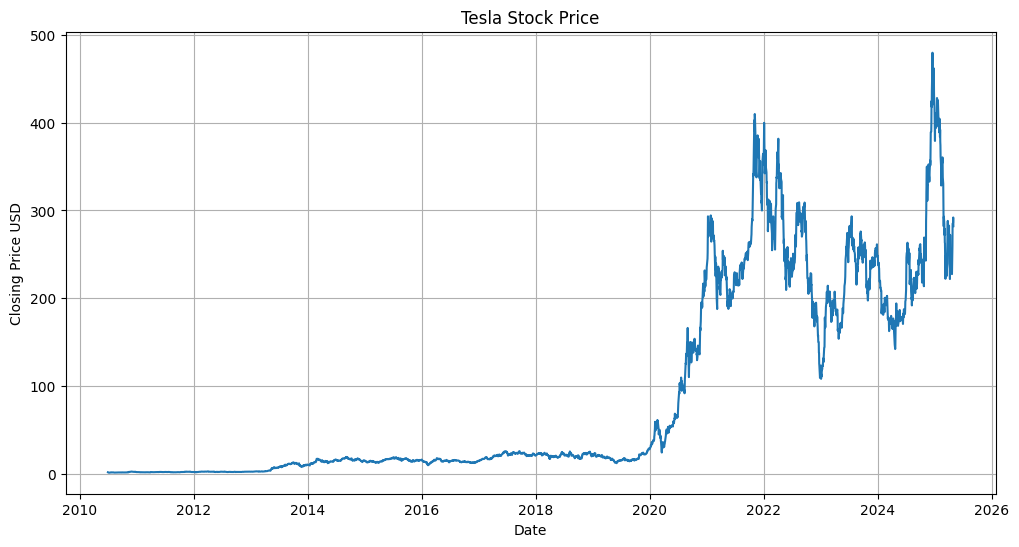

In [25]:
import matplotlib.pyplot as plt

def make_graph(data, title):
    plt.figure(figsize=(12,6))
    plt.plot(data.Date, data.Close)
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Closing Price USD')
    plt.grid(True)
    plt.show()

make_graph(tesla_data, "Tesla Stock Price")


### Question 6

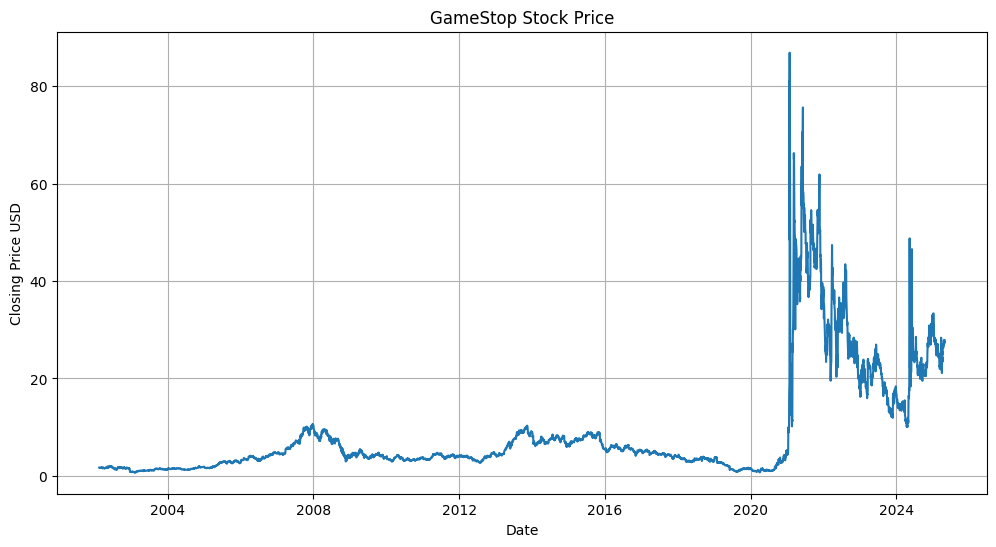

In [26]:
make_graph(gme_data, "GameStop Stock Price")